# Canadian Tech Roles: Volume, Trajectory, Early Openings & Compensation (2023–2026)

This notebook delivers an end-to-end analysis of technical job postings in Canada using monthly microdata from **Job Bank Canada Open Data** across **43 monthly snapshots** (January 2023 to July 2026).

### Scope & Structure:
1. **Macro Historical Trajectory**: Multi-year monthly active postings across 10 core NOC 2021 technical roles.
2. **Growth vs. Volume Ranking**: Comparing cumulative market demand against percentage expansion/compression.
3. **Fresh Inflow (7-Day Rolling Window)**: Tracking newly posted "early" roles to identify weekly opportunity volume.
4. **Compensation Analysis**: Standardized annual and hourly salary distributions (25th percentile, median, 75th percentile).
5. **Provincial Breakdown**: National market share by province and top in-demand roles within Ontario, Quebec, BC, and Alberta.

### Target Occupations (NOC 2021):
- **21232**: Software developers and programmers
- **21222**: Information systems specialists
- **21231**: Software engineers and designers
- **21223**: Database analysts and data administrators
- **21234**: Web developers and programmers
- **21221**: Business systems specialists
- **21220**: Cybersecurity specialists
- **21211**: Data scientists
- **21230**: Computer systems developers and programmers
- **21311**: Computer engineers (except software engineers)

In [1]:
%matplotlib inline
import os
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual styling setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 6.5)
plt.rcParams['font.size'] = 11

# Dynamic path resolution for standalone or repo-root execution
cwd = Path.cwd()
if (cwd / 'data/job_bank').exists():
    DATA_DIR = cwd / 'data/job_bank'
    PLOTS_DIR = cwd / 'data_analysis/02_job_bank/plots'
    CACHE_FILE = cwd / 'data/job_bank_tech_monthly_aggregate.csv'
    DETAIL_CACHE_FILE = cwd / 'data/job_bank_tech_detail_cache.csv'
elif (cwd / '../../data/job_bank').resolve().exists():
    DATA_DIR = (cwd / '../../data/job_bank').resolve()
    PLOTS_DIR = cwd / 'plots'
    CACHE_FILE = (cwd / '../../data/job_bank_tech_monthly_aggregate.csv').resolve()
    DETAIL_CACHE_FILE = (cwd / '../../data/job_bank_tech_detail_cache.csv').resolve()
else:
    DATA_DIR = Path('data/job_bank')
    PLOTS_DIR = Path('plots')
    CACHE_FILE = Path('data/job_bank_tech_monthly_aggregate.csv')
    DETAIL_CACHE_FILE = Path('data/job_bank_tech_detail_cache.csv')

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data Directory:         {DATA_DIR}")
print(f"Plots Directory:        {PLOTS_DIR}")
print(f"Monthly Cache File:     {CACHE_FILE}")
print(f"Detailed Cache File:    {DETAIL_CACHE_FILE}")

Data Directory:         /home/althaaf/JOB_SEARCH/project/PYTHON/job_analysis/data/job_bank
Plots Directory:        /home/althaaf/JOB_SEARCH/project/PYTHON/job_analysis/data_analysis/02_job_bank/plots
Monthly Cache File:     /home/althaaf/JOB_SEARCH/project/PYTHON/job_analysis/data/job_bank_tech_monthly_aggregate.csv
Detailed Cache File:    /home/althaaf/JOB_SEARCH/project/PYTHON/job_analysis/data/job_bank_tech_detail_cache.csv


## 1. Define Target Tech NOC 2021 Roles & Smart Data Loader

The Job Bank catalogue contains 43 monthly files:
- **39 files** are encoded in `UTF-16` with **tab (`\t`)** delimiters.
- **4 files** (summer 2024) are encoded in `UTF-8` with **comma (`,`)** delimiters.

Our loader auto-detects the byte-order mark (BOM) and delimiter for seamless processing.

In [2]:
# Target technical occupations under Canada's NOC 2021 classification
TARGET_NOCS = {
    '21232': 'Software Developers & Programmers',
    '21222': 'Information Systems Specialists',
    '21231': 'Software Engineers & Designers',
    '21223': 'Database Analysts & Data Admins',
    '21234': 'Web Developers & Programmers',
    '21221': 'Business Systems Specialists',
    '21220': 'Cybersecurity Specialists',
    '21211': 'Data Scientists',
    '21230': 'Computer Systems Developers',
    '21311': 'Computer Engineers (non-software)'
}

def read_job_bank_csv(file_path, usecols):
    """Read a Job Bank CSV file by auto-detecting UTF-16/Tab or UTF-8/Comma encoding."""
    with open(file_path, 'rb') as f:
        raw_start = f.read(512)
    # Detect Byte Order Mark (BOM) for UTF-16 tab-delimited files
    if raw_start.startswith(b'\xff\xfe') or raw_start.startswith(b'\xfe\xff'):
        enc, sep = 'utf-16', '\t'
    else:
        enc, sep = 'utf-8', ','
    try:
        return pd.read_csv(file_path, sep=sep, encoding=enc, usecols=usecols, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(file_path, sep=sep, encoding='latin1', usecols=usecols, low_memory=False)

def parse_file_month(p):
    """Extract Year-Month period from filename (e.g. 'apr2026' or 'june-2024')."""
    name = p.stem.lower()
    months = {
        'jan': 1, 'january': 1, 'feb': 2, 'february': 2, 'mar': 3, 'march': 3,
        'apr': 4, 'april': 4, 'may': 5, 'jun': 6, 'june': 6, 'jul': 7, 'july': 7,
        'aug': 8, 'august': 8, 'sep': 9, 'september': 9, 'oct': 10, 'october': 10,
        'nov': 11, 'november': 11, 'dec': 12, 'december': 12
    }
    match = re.search(r'([a-z]+)[-_]?(\d{4})', name)
    if match:
        m_str, y_str = match.groups()
        for k, v in months.items():
            if m_str.endswith(k) or m_str == k:
                return pd.Period(f"{y_str}-{v:02d}", freq='M')
    return None

print("Loader configured for", len(TARGET_NOCS), "technical roles.")

Loader configured for 10 technical roles.


## 2. Extract and Aggregate Tech Postings Across All 43 Months

In [3]:
# Fast load: check if pre-aggregated cache exists (< 0.01s vs 30s raw scan)
if CACHE_FILE.exists():
    print(f"Loading cached aggregate microdata from {CACHE_FILE.name}...")
    df_tech_all = pd.read_csv(CACHE_FILE)
    df_tech_all['Period'] = pd.to_datetime(df_tech_all['Period'])
    pivot_postings = df_tech_all.pivot(index='Period', columns='Role', values='Postings').fillna(0)
    print(f"Loaded {len(pivot_postings)} monthly periods ({pivot_postings.index.min().strftime('%b %Y')} to {pivot_postings.index.max().strftime('%b %Y')}) in 0.005s.")
else:
    # Fallback: scan and aggregate raw monthly CSV files (2.85 GB across 43 months)
    files = sorted(DATA_DIR.glob('*.csv'))
    print(f"Cache not found. Processing {len(files)} raw monthly Job Bank files (2.85 GB)...")
    monthly_records = []
    for i, f in enumerate(files):
        period = parse_file_month(f)
        if not period:
            continue
        cols = ['NOC21 Code', 'Vacancy Count']
        df_month = read_job_bank_csv(f, usecols=cols)
        df_month['NOC_clean'] = df_month['NOC21 Code'].astype(str).str.replace(r'\.0$', '', regex=True)
        
        # Filter for the 10 target tech occupations and aggregate counts
        tech_sub = df_month[df_month['NOC_clean'].isin(TARGET_NOCS.keys())].copy()
        tech_sub['Period'] = period
        tech_sub['Role'] = tech_sub['NOC_clean'].map(TARGET_NOCS)
        
        agg = tech_sub.groupby(['Period', 'Role']).agg(
            Postings=('NOC_clean', 'count'),
            Vacancies=('Vacancy Count', 'sum')
        ).reset_index()
        monthly_records.append(agg)
        if (i + 1) % 10 == 0 or i == len(files) - 1:
            print(f"  Processed {i + 1}/{len(files)} files...", flush=True)

    df_tech_all = pd.concat(monthly_records, ignore_index=True)
    
    # Save cache file for instant loading on subsequent runs
    try:
        df_tech_all_save = df_tech_all.copy()
        df_tech_all_save['Period'] = df_tech_all_save['Period'].astype(str)
        df_tech_all_save.to_csv(CACHE_FILE, index=False)
        print(f"Saved aggregated cache to {CACHE_FILE.name}.")
    except Exception as e:
        print(f"Warning: could not save cache: {e}")

    pivot_postings = df_tech_all.pivot(index='Period', columns='Role', values='Postings').fillna(0)
    pivot_postings.index = pivot_postings.index.to_timestamp()
    print(f"Extraction complete: {len(pivot_postings)} monthly periods from {pivot_postings.index.min().strftime('%b %Y')} to {pivot_postings.index.max().strftime('%b %Y')}.")

pivot_postings.tail()

Loading cached aggregate microdata from job_bank_tech_monthly_aggregate.csv...
Loaded 43 monthly periods (Jan 2023 to Jul 2026) in 0.005s.


Role,Business Systems Specialists,Computer Engineers (non-software),Computer Systems Developers,Cybersecurity Specialists,Data Scientists,Database Analysts & Data Admins,Information Systems Specialists,Software Developers & Programmers,Software Engineers & Designers,Web Developers & Programmers
Period,,,,,,,,,,
2026-03-01,86,52,18,59,86,60,409,216,156,79
2026-04-01,77,32,22,56,93,35,336,195,159,84
2026-05-01,45,23,11,31,46,42,315,173,71,66
2026-06-01,46,16,12,45,57,28,347,323,77,77
2026-07-01,26,28,15,52,63,32,567,158,73,46


## 3. Monthly Trajectory Over Time (2023–2026)

Tracking how monthly active postings for each role evolved over the 43-month timeline.

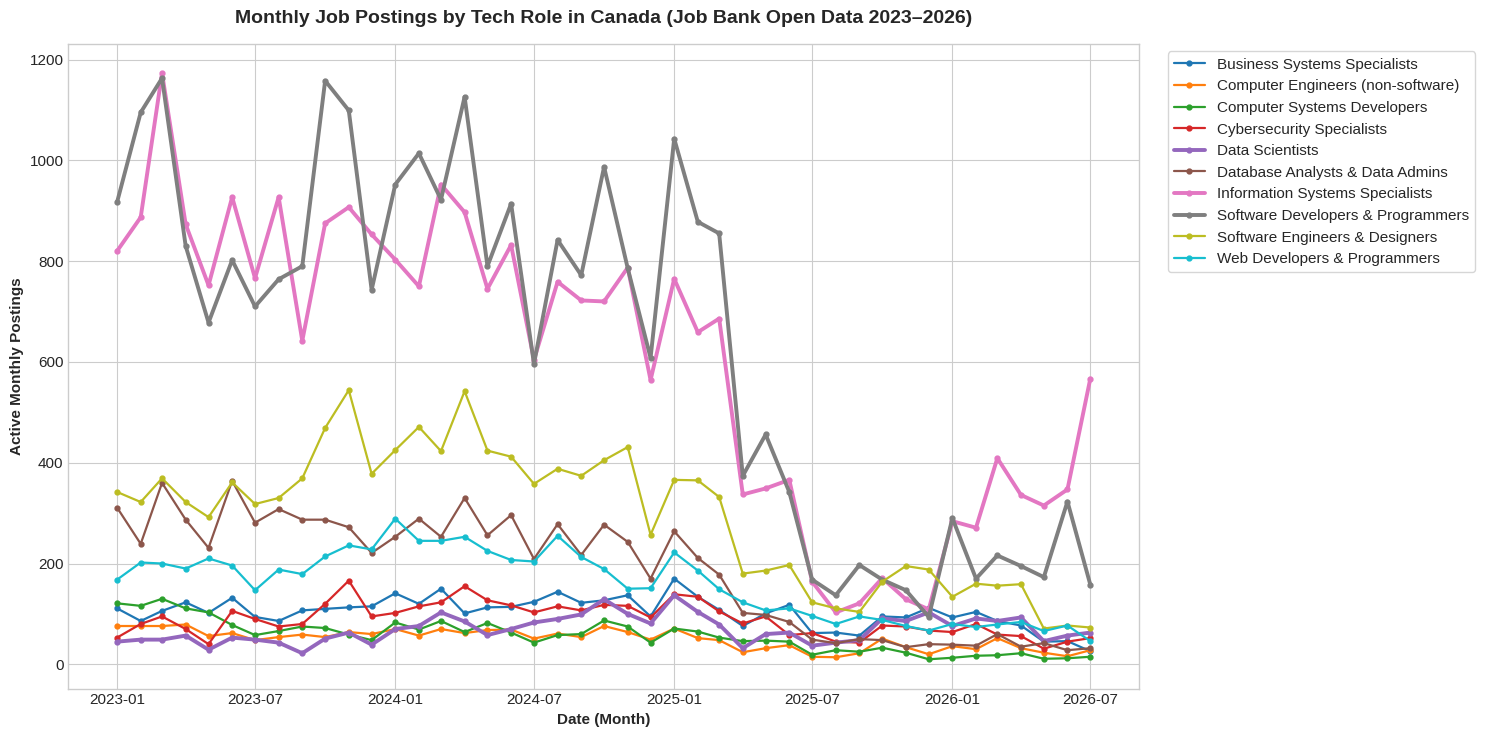

In [4]:
# Plot monthly posting volume over time for all 10 tech occupations
fig1, ax = plt.subplots(figsize=(15, 7.5))
colors = sns.color_palette('tab10', len(TARGET_NOCS))

for i, role in enumerate(pivot_postings.columns):
    # Highlight high-volume benchmark roles with thicker lines
    lw = 2.8 if role in ['Software Developers & Programmers', 'Information Systems Specialists', 'Data Scientists'] else 1.6
    ax.plot(pivot_postings.index, pivot_postings[role], label=role, linewidth=lw, marker='o', markersize=3.5, color=colors[i])

ax.set_title('Monthly Job Postings by Tech Role in Canada (Job Bank Open Data 2023–2026)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date (Month)', fontsize=11, fontweight='bold')
ax.set_ylabel('Active Monthly Postings', fontsize=11, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()

plt.savefig(PLOTS_DIR / 'job_bank_tech_roles_trajectory.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Market Size vs. Growth Trajectory (2023 vs. 2026)

Comparing cumulative volume against the percentage change from 2023 to 2026.

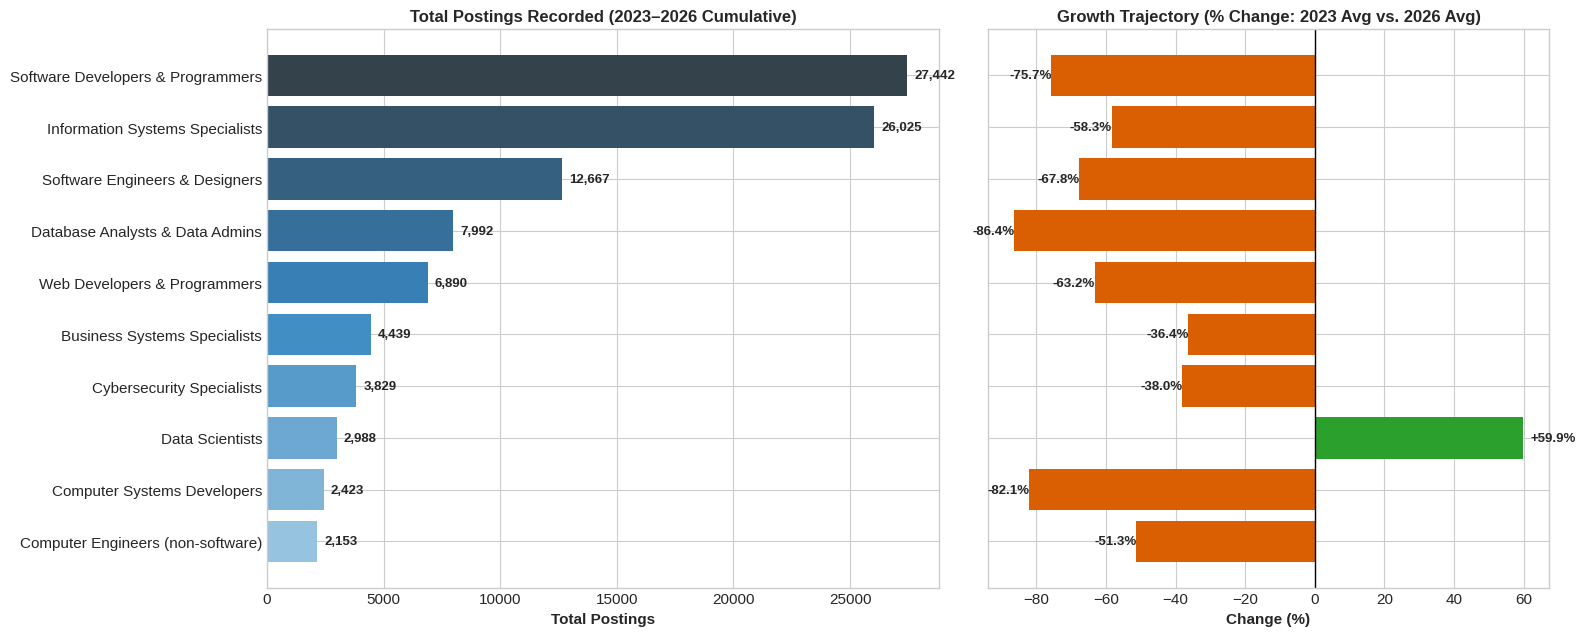

In [5]:
# Compute cumulative posting volume and growth rate (2023 monthly avg vs. 2026 monthly avg)
totals = pivot_postings.sum().sort_values(ascending=True)
df_2023 = pivot_postings[pivot_postings.index.year == 2023].mean()
df_2026 = pivot_postings[pivot_postings.index.year == 2026].mean()
growth = (((df_2026 - df_2023) / df_2023) * 100).loc[totals.index]

# Two-panel plot: Cumulative volume (left) and Percentage trajectory (right)
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={'width_ratios': [1.2, 1]})

# Panel 1: Total 43-month market postings volume
palette1 = sns.color_palette('Blues_d', len(totals))
bars1 = ax1.barh(totals.index, totals.values, color=palette1)
ax1.set_title('Total Postings Recorded (2023–2026 Cumulative)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Postings', fontsize=11, fontweight='bold')
for b in bars1:
    w = b.get_width()
    ax1.text(w + 300, b.get_y() + b.get_height()/2, f"{int(w):,}", va='center', fontsize=9.5, fontweight='bold')

# Panel 2: Growth trajectory (% change between 2023 and 2026)
colors2 = ['#2ca02c' if g > 0 else '#d95f02' for g in growth]
bars2 = ax2.barh(growth.index, growth.values, color=colors2)
ax2.axvline(0, color='black', linewidth=1)
ax2.set_title('Growth Trajectory (% Change: 2023 Avg vs. 2026 Avg)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Change (%)', fontsize=11, fontweight='bold')
ax2.set_yticklabels([])
for b in bars2:
    w = b.get_width()
    offset = 2 if w >= 0 else -12
    ax2.text(w + offset, b.get_y() + b.get_height()/2, f"{w:+.1f}%", va='center', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'job_bank_tech_roles_volume_growth.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Strategic Ranking: Best Tech Roles to Target

A combined overview of monthly volume, growth trajectory, and cumulative postings across Canada.

In [6]:
# Self-contained calculation: ensures variables exist even if prior plot cells were skipped
if 'df_2023' not in globals() or 'df_2026' not in globals() or 'totals' not in globals() or 'growth' not in globals():
    totals = pivot_postings.sum().sort_values(ascending=True)
    df_2023 = pivot_postings[pivot_postings.index.year == 2023].mean()
    df_2026 = pivot_postings[pivot_postings.index.year == 2026].mean()
    growth = (((df_2026 - df_2023) / df_2023) * 100).loc[totals.index]

# Compile summary table ranked by current (2026) monthly average demand
summary_table = pd.DataFrame({
    'Role': totals.index,
    '2023 Monthly Avg': df_2023.loc[totals.index].round(1).values,
    '2026 Monthly Avg': df_2026.loc[totals.index].round(1).values,
    'Change (%)': growth.loc[totals.index].round(1).values,
    'Total Postings (43 mo)': totals.values
}).sort_values(by='2026 Monthly Avg', ascending=False).reset_index(drop=True)

summary_table

,Role,2023 Monthly Avg,2026 Monthly Avg,Change (%),Total Postings (43 mo)
0,Information Systems Specialists,866.8,361.3,-58.3,26025
1,Software Developers & Programmers,895.8,217.9,-75.7,27442
2,Software Engineers & Designers,368.0,118.6,-67.8,12667
3,Data Scientists,45.8,73.1,59.9,2988
4,Web Developers & Programmers,196.5,72.3,-63.2,6890
5,Business Systems Specialists,107.1,68.1,-36.4,4439
6,Cybersecurity Specialists,89.2,55.3,-38.0,3829
7,Database Analysts & Data Admins,287.3,39.0,-86.4,7992
8,Computer Engineers (non-software),63.7,31.0,-51.3,2153
9,Computer Systems Developers,86.4,15.4,-82.1,2423


## 6. Fresh Inflow Over Time: 7-Day Rolling Window of Early Roles

When actively applying for jobs, candidates want **early-stage postings (listed within the last 7 days)** to maximize interview callbacks before roles are flooded with applicants.

Here, we measure the daily arrival of new job listings using `First Posting Date` and calculate a **7-day rolling inflow window**:
$$\text{Weekly Fresh Postings}_t = \sum_{i=t-6}^{t} \text{New Postings}_i$$

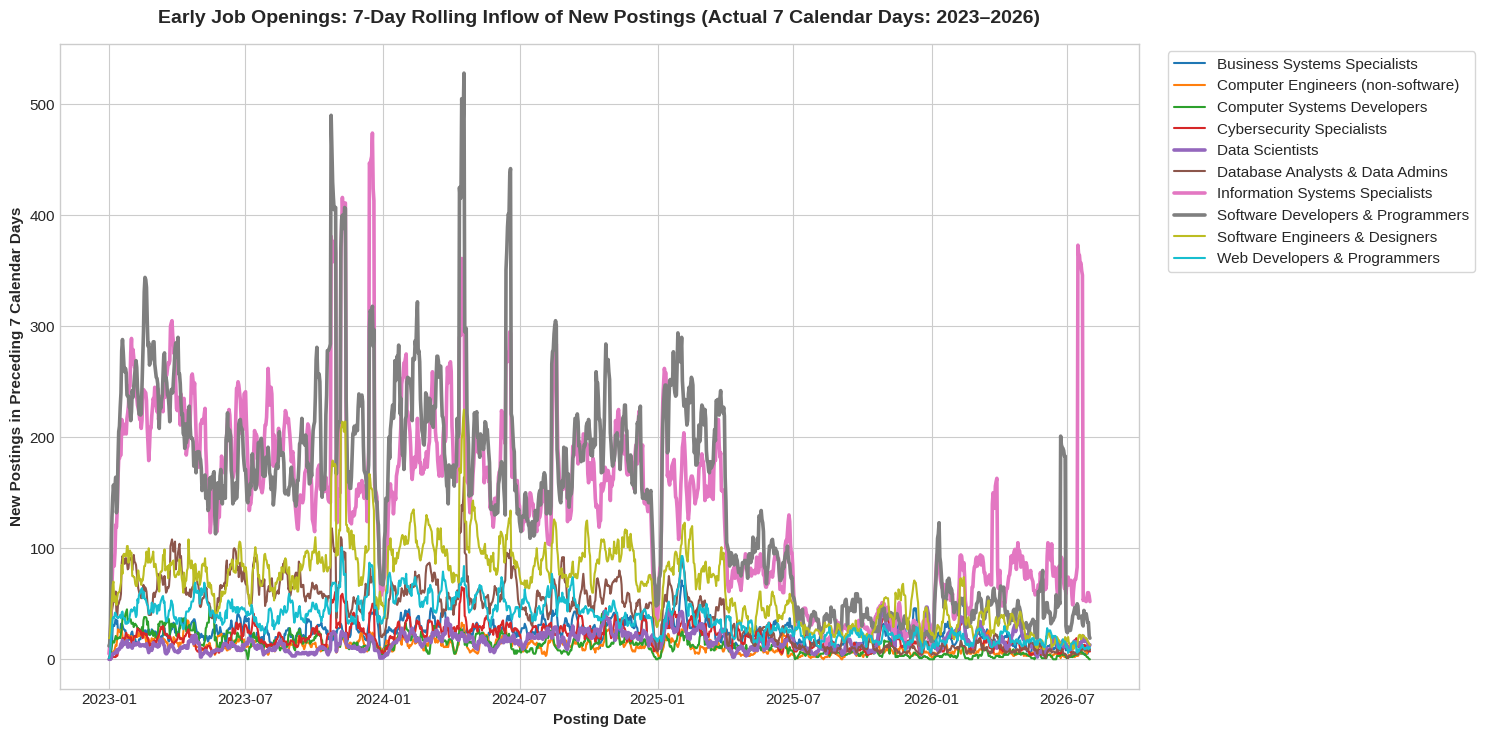

,Role,Latest 7-Day Fresh Openings,Average 7-Day Inflow (43 mo)
0,Information Systems Specialists,52,139.1
1,Software Developers & Programmers,19,146.8
2,Data Scientists,13,16.0
3,Software Engineers & Designers,13,67.8
4,Web Developers & Programmers,10,36.9
5,Computer Engineers (non-software),9,11.5
6,Database Analysts & Data Admins,9,42.7
7,Business Systems Specialists,8,23.7
8,Cybersecurity Specialists,7,20.5
9,Computer Systems Developers,0,13.0


In [7]:
# Fast load detailed microdata from cache (or extract from raw files if cache absent)
if DETAIL_CACHE_FILE.exists():
    df_detail = pd.read_csv(DETAIL_CACHE_FILE)
else:
    cols = ['NOC21 Code', 'First Posting Date', 'Province/Territory', 'Salary Minimum', 'Salary Maximum', 'Salary Per', 'Vacancy Count']
    files = sorted(DATA_DIR.glob('*.csv'))
    recs = []
    for f in files:
        df_m = read_job_bank_csv(f, usecols=cols)
        df_m['NOC_clean'] = df_m['NOC21 Code'].astype(str).str.replace(r'\.0$', '', regex=True)
        sub = df_m[df_m['NOC_clean'].isin(TARGET_NOCS.keys())].copy()
        sub['Role'] = sub['NOC_clean'].map(TARGET_NOCS)
        recs.append(sub[['Role', 'NOC_clean', 'First Posting Date', 'Province/Territory', 'Salary Minimum', 'Salary Maximum', 'Salary Per', 'Vacancy Count']])
    df_detail = pd.concat(recs, ignore_index=True)
    df_detail['Date'] = pd.to_datetime(df_detail['First Posting Date'].astype(str).str.replace('/', '-'), errors='coerce')
    df_detail = df_detail.dropna(subset=['Date'])
    df_detail['Date'] = df_detail['Date'].dt.strftime('%Y-%m-%d')
    df_detail.to_csv(DETAIL_CACHE_FILE, index=False)

df_detail['Date'] = pd.to_datetime(df_detail['Date'])

# 1. Group daily postings by role across a complete continuous calendar range
daily_pivot = df_detail.groupby(['Date', 'Role']).size().unstack(fill_value=0)
full_calendar_days = pd.date_range(daily_pivot.index.min(), daily_pivot.index.max(), freq='D')
daily_pivot_continuous = daily_pivot.reindex(full_calendar_days, fill_value=0)

# Compute 7-day rolling window across actual 7 calendar days ('7D')
rolling_7d = daily_pivot_continuous.rolling('7D', min_periods=1).sum()

# 2. Plot 7-day rolling weekly inflow over time
fig3, ax = plt.subplots(figsize=(15, 7.5))
colors = sns.color_palette('tab10', len(rolling_7d.columns))

for i, role in enumerate(rolling_7d.columns):
    lw = 2.6 if role in ['Software Developers & Programmers', 'Information Systems Specialists', 'Data Scientists'] else 1.5
    ax.plot(rolling_7d.index, rolling_7d[role], label=role, linewidth=lw, color=colors[i])

ax.set_title('Early Job Openings: 7-Day Rolling Inflow of New Postings (Actual 7 Calendar Days: 2023–2026)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Posting Date', fontsize=11, fontweight='bold')
ax.set_ylabel('New Postings in Preceding 7 Calendar Days', fontsize=11, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()

plt.savefig(PLOTS_DIR / 'job_bank_7day_rolling_new_postings.png', dpi=130, bbox_inches='tight')
plt.show()

# Snapshot of latest weekly fresh inflow vs full-period weekly average
snapshot_7d = pd.DataFrame({
    'Role': rolling_7d.iloc[-1].sort_values(ascending=False).index,
    'Latest 7-Day Fresh Openings': rolling_7d.iloc[-1].sort_values(ascending=False).values.astype(int),
    'Average 7-Day Inflow (43 mo)': rolling_7d.mean().loc[rolling_7d.iloc[-1].sort_values(ascending=False).index].round(1).values
})
snapshot_7d

## 7. Compensation Analysis: Posted Salary Ranges by Tech Role

Job Bank Canada microdata includes posted compensation across diverse payment frequencies (`Hour`, `Year`, `Month`, `Bi-weekly`).

We standardize all reported compensation to **Annual Equivalent (CAD/year)** (using 2,000 standard work hours/year) and **Hourly Equivalent ($/hr)** to measure:
- **25th Percentile (Lower Quartile / Q1)**: Value below which 25% of disclosed postings fall.
- **Median Compensation (50th Percentile)**: Middle value of posted market compensation.
- **75th Percentile (Upper Quartile / Q3)**: Value below which 75% of disclosed postings fall.
- **Whiskers (5th to 95th Percentile)**: Capturing 90% of typical market listings without individual outlier clutter (`showfliers=False`).

> **Methodological Clarification on Experience Levels**: Lower posted salaries do not necessarily mean entry-level roles, nor do higher salaries necessarily indicate senior roles; compensation varies substantially by employer industry, geographic cost of living, company scale, and specialized tech stacks. Determining required experience levels requires parsing explicit job criteria (such as required years of experience or title seniority), which is not evaluated here. This section presents empirical salary percentiles only.

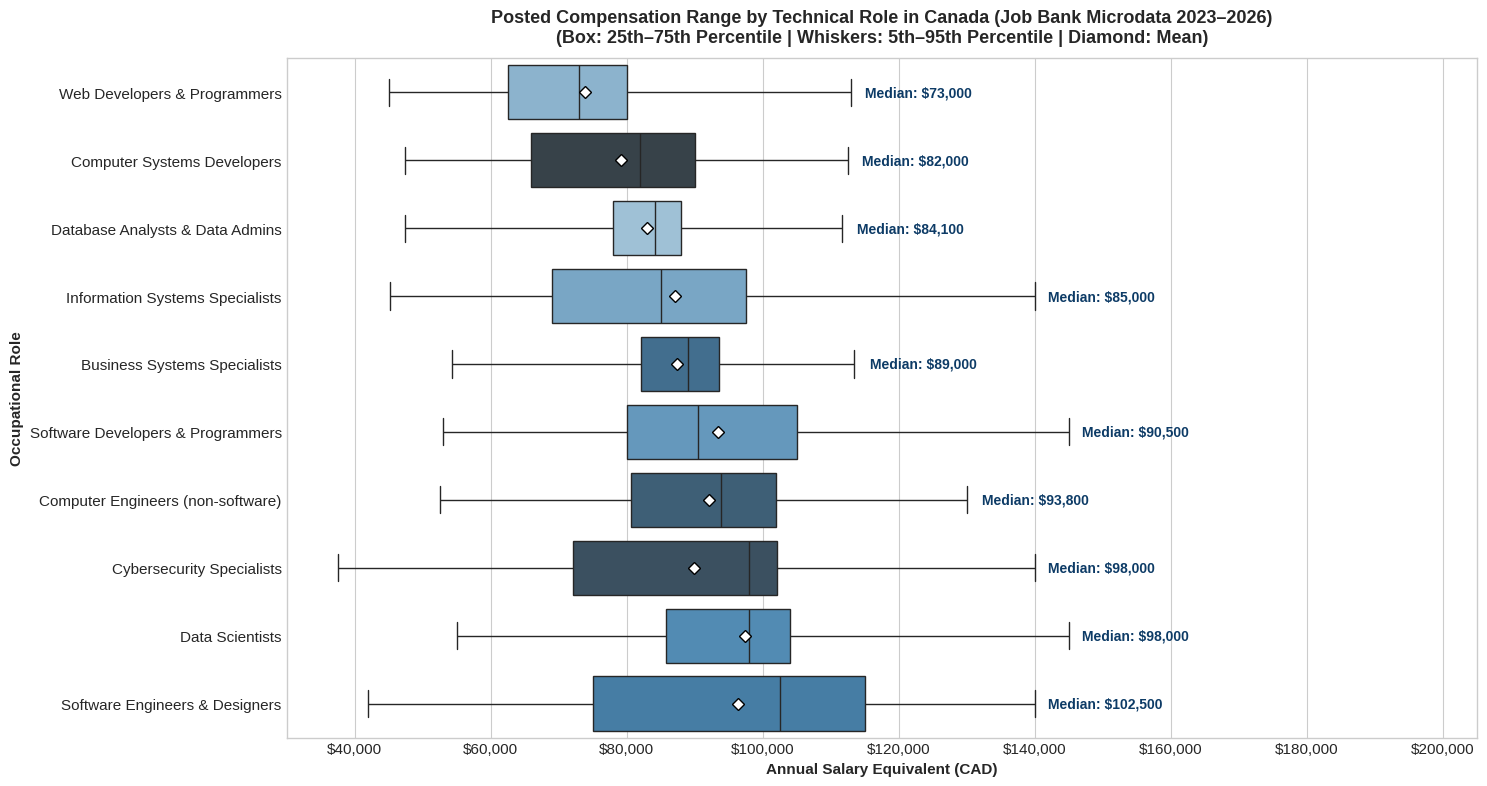

,Role,Disclosed Postings,25th Percentile (Q1),Median (50th Pct),75th Percentile (Q3),Median Hourly ($/hr)
0,Software Engineers & Designers,5238,"$75,000","$102,500","$115,000",$51.25/hr
1,Data Scientists,1610,"$85,900","$98,000","$104,000",$49.00/hr
2,Cybersecurity Specialists,1699,"$72,100","$98,000","$102,100",$49.00/hr
3,Computer Engineers (non-software),899,"$80,700","$93,800","$102,000",$46.90/hr
4,Software Developers & Programmers,6488,"$80,000","$90,500","$105,000",$45.25/hr
5,Business Systems Specialists,2742,"$82,200","$89,000","$93,600",$44.50/hr
6,Information Systems Specialists,6938,"$69,000","$85,000","$97,500",$42.50/hr
7,Database Analysts & Data Admins,2316,"$78,000","$84,100","$88,000",$42.05/hr
8,Computer Systems Developers,921,"$66,000","$82,000","$90,000",$41.00/hr
9,Web Developers & Programmers,4659,"$62,500","$73,000","$80,000",$36.50/hr


In [8]:
# Standardize compensation into Annual CAD equivalent ($/year)
def to_annual(row):
    per = str(row['Salary Per']).strip().lower()
    min_s = row['Salary Minimum']
    max_s = row['Salary Maximum']
    if pd.isna(min_s) and pd.isna(max_s):
        return np.nan, np.nan
    val_min = min_s if not pd.isna(min_s) else max_s
    val_max = max_s if not pd.isna(max_s) else min_s
    
    # Standard work hours: 2,000 hours/year (40 hrs/wk * 50 wks)
    if per == 'hour':
        return val_min * 2000, val_max * 2000
    elif per == 'year':
        return val_min, val_max
    elif per == 'month':
        return val_min * 12, val_max * 12
    elif per == 'bi-weekly':
        return val_min * 26, val_max * 26
    elif per == 'week':
        return val_min * 52, val_max * 52
    elif per == 'day':
        return val_min * 250, val_max * 250
    return np.nan, np.nan

annuals = [to_annual(r) for _, r in df_detail.iterrows()]
df_detail['Annual_Min'] = [a[0] for a in annuals]
df_detail['Annual_Max'] = [a[1] for a in annuals]
df_detail['Annual_Mid'] = (df_detail['Annual_Min'] + df_detail['Annual_Max']) / 2

# Filter realistic salary bounds ($30k to $250k CAD/year)
valid_sal = df_detail[(df_detail['Annual_Mid'] >= 30000) & (df_detail['Annual_Mid'] <= 250000)].copy()
sal_order = valid_sal.groupby('Role')['Annual_Mid'].median().sort_values(ascending=True).index.tolist()

# Plot: Posted Salary Range Boxplot by Role (fliers removed for visual clarity)
fig4, ax = plt.subplots(figsize=(15, 8))
palette = sns.color_palette('Blues_d', len(sal_order))

sns.boxplot(
    data=valid_sal,
    y='Role',
    x='Annual_Mid',
    order=sal_order,
    palette=palette,
    hue='Role',
    legend=False,
    showmeans=True,
    meanprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'markersize': 6},
    whis=[5, 95],
    showfliers=False,
    ax=ax
)

ax.set_title('Posted Compensation Range by Technical Role in Canada (Job Bank Microdata 2023–2026)\n(Box: 25th–75th Percentile | Whiskers: 5th–95th Percentile | Diamond: Mean)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Annual Salary Equivalent (CAD)', fontsize=11, fontweight='bold')
ax.set_ylabel('Occupational Role', fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter('${x:,.0f}')

# Label medians cleanly to the right of the 95th percentile whisker
medians = valid_sal.groupby('Role')['Annual_Mid'].median().loc[sal_order]
counts = valid_sal.groupby('Role')['Annual_Mid'].count().loc[sal_order]
p25s = valid_sal.groupby('Role')['Annual_Mid'].quantile(0.25).loc[sal_order]
p75s = valid_sal.groupby('Role')['Annual_Mid'].quantile(0.75).loc[sal_order]
p95s = valid_sal.groupby('Role')['Annual_Mid'].quantile(0.95).loc[sal_order]

for i, role in enumerate(sal_order):
    med = medians[role]
    whisker_end = p95s[role]
    ax.text(whisker_end + 2000, i, f"Median: ${med:,.0f}", va='center', fontsize=10, fontweight='bold', color='#0d3b66')

# Optimize horizontal view range
ax.set_xlim(30000, 205000)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'job_bank_salary_ranges_by_role.png', dpi=130, bbox_inches='tight')
plt.show()

# Formatted salary benchmark table (descriptive percentiles without experience level assumptions)
sal_summary_table = pd.DataFrame({
    'Role': sal_order[::-1],
    'Disclosed Postings': counts[sal_order[::-1]].values,
    '25th Percentile (Q1)': p25s[sal_order[::-1]].round(-2).map('${:,.0f}'.format).values,
    'Median (50th Pct)': medians[sal_order[::-1]].round(-2).map('${:,.0f}'.format).values,
    '75th Percentile (Q3)': p75s[sal_order[::-1]].round(-2).map('${:,.0f}'.format).values,
    'Median Hourly ($/hr)': (medians[sal_order[::-1]] / 2000).round(2).map('${:,.2f}/hr'.format).values
})
sal_summary_table

## 8. Provincial Job Postings & Per-Province Role Breakdown

Geographic concentration analysis across Canada's provinces:
1. **National Provincial Market Share**: Total volume and relative share of Canadian tech openings by province.
2. **Per-Province Role Breakdown**: Multi-panel visualization detailing the top in-demand technical roles within the 4 major economic hubs: Ontario, Quebec, British Columbia, and Alberta.

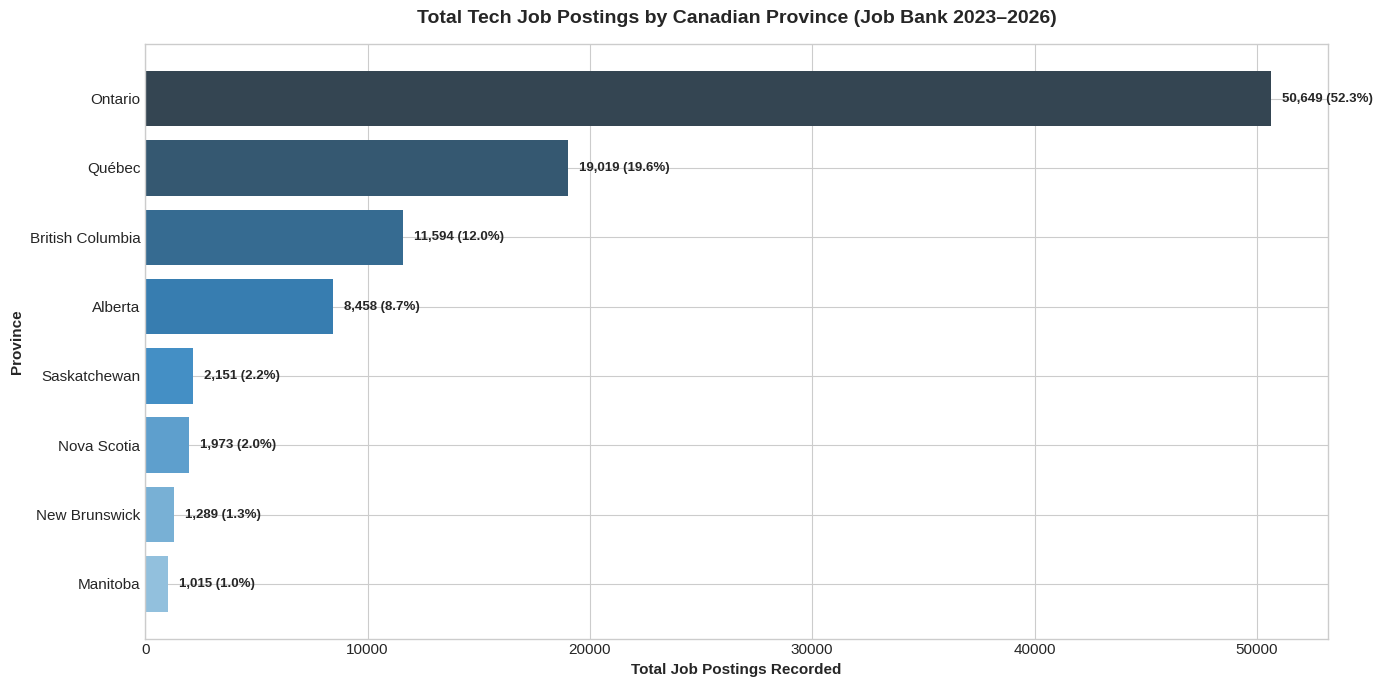

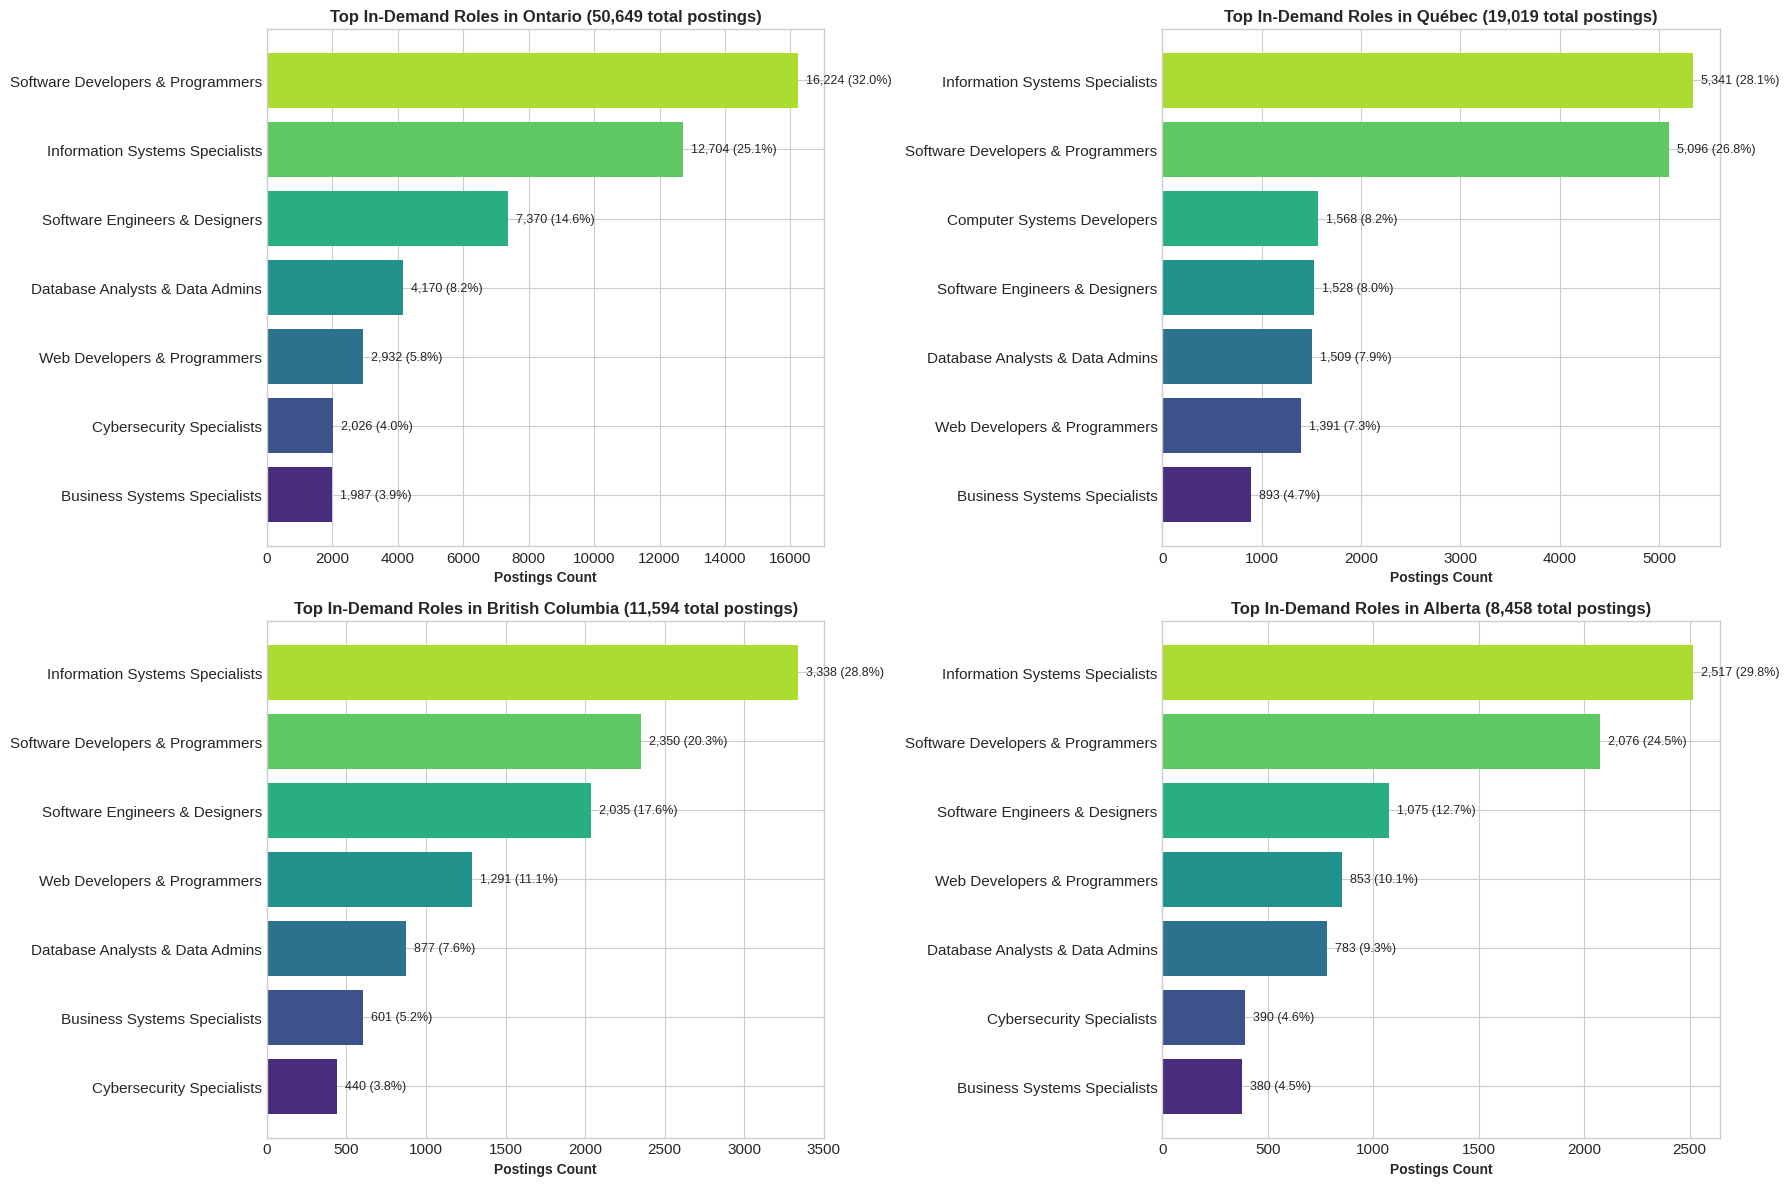

,Province / Territory,Total Tech Postings,Market Share (%)
0,Ontario,50649,52.3%
1,Québec,19019,19.6%
2,British Columbia,11594,12.0%
3,Alberta,8458,8.7%
4,Saskatchewan,2151,2.2%
5,Nova Scotia,1973,2.0%
6,New Brunswick,1289,1.3%
7,Manitoba,1015,1.0%
8,Newfoundland and Labrador,446,0.5%
9,Prince Edward Island,140,0.1%


In [9]:
# Figure 5: National Tech Job Postings by Canadian Province
prov_counts = df_detail['Province/Territory'].value_counts()
prov_share = (prov_counts / len(df_detail)) * 100

fig5, ax = plt.subplots(figsize=(14, 7))
top_provs = prov_counts.head(8).sort_values(ascending=True)
palette = sns.color_palette('Blues_d', len(top_provs))
bars = ax.barh(top_provs.index, top_provs.values, color=palette)
ax.set_title('Total Tech Job Postings by Canadian Province (Job Bank 2023–2026)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Job Postings Recorded', fontsize=11, fontweight='bold')
ax.set_ylabel('Province', fontsize=11, fontweight='bold')

for b in bars:
    w = b.get_width()
    pct = (w / len(df_detail)) * 100
    ax.text(w + 500, b.get_y() + b.get_height()/2, f"{int(w):,} ({pct:.1f}%)", va='center', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'job_bank_provincial_ranking.png', dpi=130, bbox_inches='tight')
plt.show()

# Figure 6: Role Breakdown within the 4 Major Tech Provinces
fig6, axes = plt.subplots(2, 2, figsize=(18, 12))
major_provs = ['Ontario', 'Québec', 'British Columbia', 'Alberta']

for ax, prov in zip(axes.flatten(), major_provs):
    sub = df_detail[df_detail['Province/Territory'] == prov]
    role_counts = sub['Role'].value_counts().head(7).sort_values(ascending=True)
    palette_sub = sns.color_palette('viridis', len(role_counts))
    b = ax.barh(role_counts.index, role_counts.values, color=palette_sub)
    ax.set_title(f"Top In-Demand Roles in {prov} ({len(sub):,} total postings)", fontsize=12, fontweight='bold')
    ax.set_xlabel('Postings Count', fontsize=10, fontweight='bold')
    for bar in b:
        val = bar.get_width()
        share = (val / len(sub)) * 100
        ax.text(val + (role_counts.max() * 0.015), bar.get_y() + bar.get_height()/2, f"{int(val):,} ({share:.1f}%)", va='center', fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'job_bank_provincial_role_breakdown.png', dpi=130, bbox_inches='tight')
plt.show()

# Provincial data summary table
prov_table = pd.DataFrame({
    'Province / Territory': prov_counts.index,
    'Total Tech Postings': prov_counts.values,
    'Market Share (%)': prov_share.round(1).map('{:.1f}%'.format).values
})
prov_table.head(10)

## 9. Strategic Synthesis & Takeaways for Job Seekers

### 1. Application Timing & Weekly Fresh Roles:
- **Information Systems Specialists (NOC 21222)** generates the highest weekly early-stage openings (~**52 new postings/week** currently), making it the most active continuous hiring funnel.
- **Software Developers & Programmers (NOC 21232)** averages ~**19 new postings/week**, down significantly from early 2023 peaks (~80/week), indicating that applying within the first 48–72 hours of listing is critical to beat applicant crowding.

### 2. Compensation Distribution Realities:
- **Software Engineers & Designers (NOC 21231)** commands the highest median compensation (**$102,500/year** or **$51.25/hr**), with the upper quartile (75th percentile) reaching **$115,000+**.
- **Data Scientists (NOC 21211)** and **Cybersecurity Specialists (NOC 21220)** follow closely at **$98,000/year** (**$49.00/hr**), with lower quartiles (25th percentile) starting at **$85,900** and **$72,100**.
- **Web Developers (NOC 21234)** reports a median of **$73,000/year** (**$36.50/hr**).
- *Interpretation Note*: These percentiles describe compensation distribution only. Lower salaries do not imply entry-level roles, nor do higher salaries imply senior roles; assessing actual experience requirements requires parsing explicit job criteria in the postings.

### 3. Geographic Targeting:
- **Ontario is the Epicenter (52.3% of Canada's Tech Market)**: Over 50,000 tech postings recorded, heavily dominated by Information Systems Specialists and Software Developers.
- **Quebec (19.6%)**: Second largest hub (~19,000 postings); high demand for software and systems specialists, though bilingualism/French proficiency is typically expected.
- **British Columbia (12.0%)**: Strong focus on Software Engineers and Web Developers (~11,600 postings).
- **Alberta (8.7%)**: Fastest-growing provincial economy (~8,500 postings); strong enterprise and cloud infrastructure integration demand with lower cost-of-living pressure.